# Phase 5: MTM + Greeks + VaR

Aggregate LSMC valuation results into MTM, Greek sensitivities, VaR/CVaR, and stress scenarios. This notebook is generated from `bess_valuation_full.ipynb` Phase 5 and requires saved Phase 4 artefacts and fails loudly if they are missing.


In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Bootstrap imports from the project root, then use the shared helper.
_ROOT_CANDIDATE = Path.cwd()
for candidate in [_ROOT_CANDIDATE, *_ROOT_CANDIDATE.parents]:
    if (candidate / "src").is_dir() and (candidate / "data").is_dir():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise RuntimeError("Could not find project root containing src/ and data/.")

from src.utils import find_project_root

PROJECT_ROOT = find_project_root(_ROOT_CANDIDATE)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED = PROJECT_ROOT / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings("ignore")

from src.config import ASSET, FINANCE, DEGRADATION, LSMC, SCHWARTZ_SMITH, PCA_SHAPE, IMBALANCE, ANCILLARY
from src.valuation.mtm import aggregate_mtm, MtmComponents
from src.valuation.greeks import GreekEngine, print_greek_ladder, greeks_to_dict
from src.valuation.var_cvar import (
    compute_risk_metrics, risk_metrics_multi_alpha, run_scenarios,
    print_risk_summary, print_scenario_table, scenarios_to_dict,
)

print("Imports OK")


Imports OK


## 1. Load LSMC Results (Phase 4)


In [2]:
# Load saved Phase 4 output. Do not silently fall back to a mini dev run:
# Phase 5 MTM annualisation is only meaningful when Phase 4 artefacts exist.
import pickle
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

if "PROCESSED" not in globals():
    _ROOT_CANDIDATE = Path.cwd()
    for candidate in [_ROOT_CANDIDATE, *_ROOT_CANDIDATE.parents]:
        if (candidate / "src").is_dir() and (candidate / "data").is_dir():
            PROJECT_ROOT = candidate
            if str(PROJECT_ROOT) not in sys.path:
                sys.path.insert(0, str(PROJECT_ROOT))
            break
    else:
        raise RuntimeError("Could not find project root containing src/ and data/.")
    PROCESSED = PROJECT_ROOT / "data" / "processed"

warnings.filterwarnings("ignore")

from src.config import ASSET, FINANCE, DEGRADATION, LSMC, SCHWARTZ_SMITH, PCA_SHAPE, IMBALANCE, ANCILLARY
from src.valuation.mtm import aggregate_mtm, MtmComponents
from src.valuation.greeks import GreekEngine, print_greek_ladder, greeks_to_dict
from src.valuation.var_cvar import (
    compute_risk_metrics, risk_metrics_multi_alpha, run_scenarios,
    print_risk_summary, print_scenario_table, scenarios_to_dict,
)

RESULT_PATH  = PROCESSED / "lsmc_valuation_result.pkl"
POLICY_PATH  = PROCESSED / "lsmc_policy.pkl"
BUNDLE_PATH  = PROCESSED / "sim_bundle.pkl"
required = [RESULT_PATH, POLICY_PATH, BUNDLE_PATH]
missing = [p for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Phase 5 requires real Phase 4 artefacts. Missing:\n"
        + "\n".join(f"  - {p}" for p in missing)
        + "\n\nRun notebooks/04_lsmc_valuation.ipynb first."
    )

with open(RESULT_PATH, "rb") as f:
    val_result = pickle.load(f)
with open(POLICY_PATH, "rb") as f:
    policy = pickle.load(f)
with open(BUNDLE_PATH, "rb") as f:
    bundle = pickle.load(f)

print(f"Loaded Phase-4 valuation result: {RESULT_PATH}")
print(f"Loaded Phase-4 policy:           {POLICY_PATH}")
print(f"Loaded simulation bundle:        {BUNDLE_PATH}")
print(f"val_result: {len(val_result.pv_paths):,} paths  |  "
      f"MTM mean = GBP {val_result.mtm_mean:,.0f}")


Loaded Phase-4 valuation result: G:\My Drive\Research\bess_project\data\processed\lsmc_valuation_result.pkl
Loaded Phase-4 policy:           G:\My Drive\Research\bess_project\data\processed\lsmc_policy.pkl
Loaded simulation bundle:        G:\My Drive\Research\bess_project\data\processed\sim_bundle.pkl
val_result: 250 paths  |  MTM mean = GBP 26,799


## 2. MTM Aggregation


In [3]:
mtm = aggregate_mtm(
    val_result,
    asset_cfg  = ASSET,
    fin_cfg    = FINANCE,
    deg_cfg    = DEGRADATION,
    contracts  = [],    # fully merchant base case
    verbose    = True,
)



  MTM Summary — 100 MW / 200 MWh BESS
  Life: 15 yr  |  alpha_merchant: 100%
  Annuity factor (wacc=9%, decay=1.5%): 8.11x
  merchant                      +      145  GBP/MW/yr
  toll                          +        0  GBP/MW/yr
  floor_contracted              +        0  GBP/MW/yr
  cm                            +    1,051  GBP/MW/yr
  floor_optionality             +   15,589  GBP/MW/yr
  optimiser_fee                       -62  GBP/MW/yr
  opex_fixed                       -5,180  GBP/MW/yr
  augmentation                    -12,527  GBP/MW/yr
  total_mean                       -2,034  GBP/MW/yr
  total_std                     +      287  GBP/MW/yr
  total_p5                         -2,393  GBP/MW/yr
  total_p95                        -1,523  GBP/MW/yr



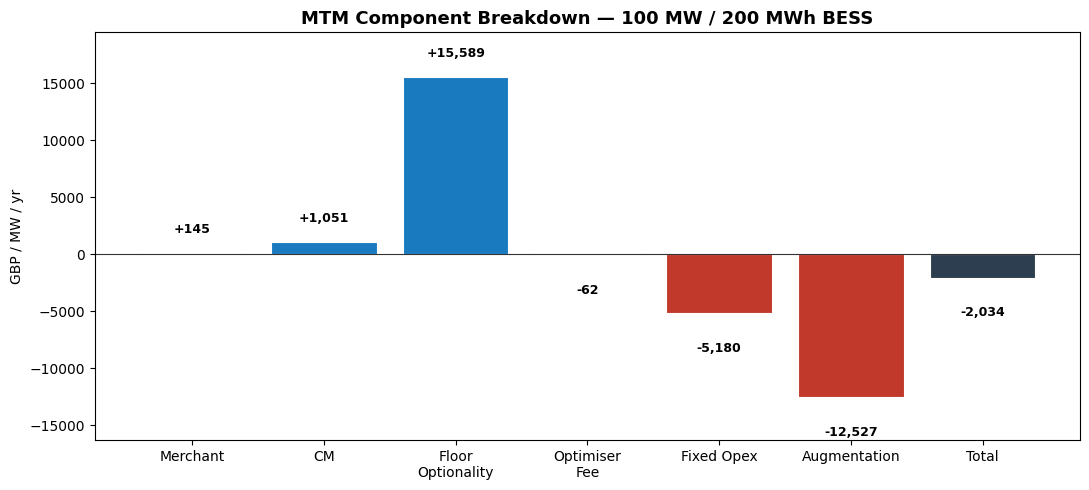

In [4]:
# Component bar chart
fig, ax = plt.subplots(figsize=(11, 5))

summary = mtm.summary_gbp_mw_yr()
labels = [
    "Merchant", "CM", "Floor\nOptionality",
    "Optimiser\nFee", "Fixed Opex", "Augmentation", "Total"
]
keys = [
    "merchant", "cm", "floor_optionality",
    "optimiser_fee", "opex_fixed", "augmentation", "total_mean"
]
vals = [summary[k] for k in keys]
colors = ["#1a7abf" if v >= 0 else "#c0392b" for v in vals[:-1]] + ["#2c3e50"]

bars = ax.bar(labels, vals, color=colors, edgecolor="white", linewidth=0.8)
ax.axhline(0, color="#333", linewidth=0.8)
for bar, val in zip(bars, vals):
    sign = "+" if val >= 0 else ""
    ax.text(bar.get_x() + bar.get_width()/2, val + (1500 if val >= 0 else -2500),
            f"{sign}{val:,.0f}", ha="center", va="bottom" if val >= 0 else "top",
            fontsize=9, fontweight="bold")

ax.set_ylabel("GBP / MW / yr")
ax.set_title(f"MTM Component Breakdown — {ASSET["power_mw"]:.0f} MW / "
             f"{ASSET["energy_mwh"]:.0f} MWh BESS", fontsize=13, fontweight="bold")
ax.set_ylim(min(vals) * 1.3, max(vals) * 1.25)
plt.tight_layout()
plt.savefig(PROCESSED / "mtm_components.png", dpi=150, bbox_inches="tight")
plt.show()


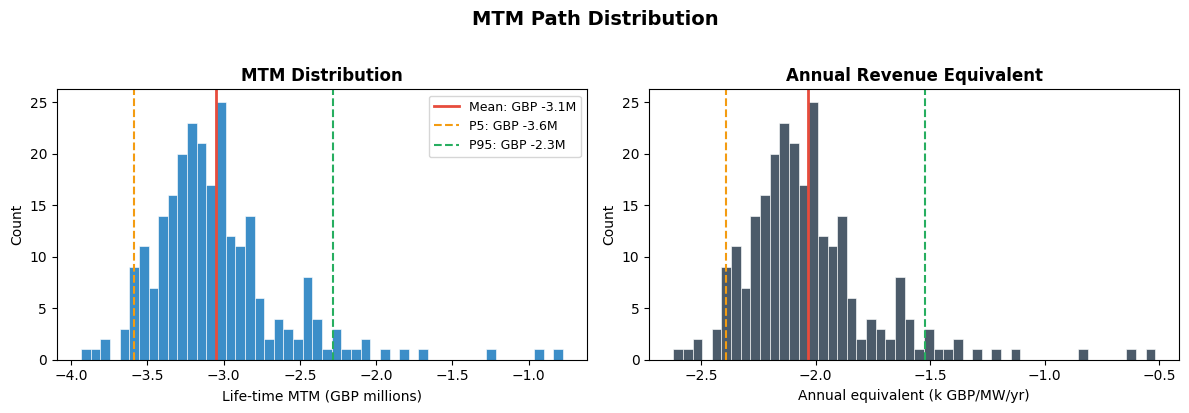

In [5]:
# MTM PV distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

paths_m = mtm.mtm_paths / 1e6
ax = axes[0]
ax.hist(paths_m, bins=50, color="#1a7abf", edgecolor="white", linewidth=0.5, alpha=0.85)
ax.axvline(mtm.mtm_mean/1e6,  color="#e74c3c", lw=2, label=f"Mean: GBP {mtm.mtm_mean/1e6:.1f}M")
ax.axvline(mtm.mtm_p5/1e6,   color="#f39c12", lw=1.5, ls="--", label=f"P5: GBP {mtm.mtm_p5/1e6:.1f}M")
ax.axvline(mtm.mtm_p95/1e6,  color="#27ae60", lw=1.5, ls="--", label=f"P95: GBP {mtm.mtm_p95/1e6:.1f}M")
ax.set_xlabel("Life-time MTM (GBP millions)")
ax.set_ylabel("Count")
ax.set_title("MTM Distribution", fontweight="bold")
ax.legend(fontsize=9)

# GBP/MW/yr scale
ax = axes[1]
annual_paths = mtm.mtm_paths / (mtm.power_mw * mtm.life_years) / 1e3  # k GBP/MW/yr
ax.hist(annual_paths, bins=50, color="#2c3e50", edgecolor="white", linewidth=0.5, alpha=0.85)
ax.axvline(np.mean(annual_paths), color="#e74c3c", lw=2)
ax.axvline(np.percentile(annual_paths, 5),  color="#f39c12", lw=1.5, ls="--")
ax.axvline(np.percentile(annual_paths, 95), color="#27ae60", lw=1.5, ls="--")
ax.set_xlabel("Annual equivalent (k GBP/MW/yr)")
ax.set_ylabel("Count")
ax.set_title("Annual Revenue Equivalent", fontweight="bold")

plt.suptitle("MTM Path Distribution", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(PROCESSED / "mtm_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Greek Ladder


In [6]:
# Initialise Greek engine
ss_p, hpfc_p, imb_p, anc_p = None, None, None, None
try:
    from src.processes.simulate import default_params_from_config
    ss_p, hpfc_p, imb_p, anc_p = default_params_from_config()
except Exception as e:
    print(f"Warning: {e}")
    from src.config import SCHWARTZ_SMITH, PCA_SHAPE, IMBALANCE, ANCILLARY
    ss_p, hpfc_p, imb_p, anc_p = SCHWARTZ_SMITH, PCA_SHAPE, IMBALANCE, ANCILLARY

greek_engine = GreekEngine(
    bundle      = bundle,
    policy      = policy,
    val_result  = val_result,
    mtm         = mtm,
    asset_cfg   = ASSET,
    fin_cfg     = FINANCE,
    deg_cfg     = DEGRADATION,
    lsmc_cfg    = LSMC,
    ss_params   = ss_p,
    hpfc_params = hpfc_p,
    imb_params  = imb_p,
    anc_params  = anc_p,
    n_paths_greek = 300,    # reduced for Greek re-solves
    verbose     = True,
)
print("Greek engine ready")


Greek engine ready


In [7]:
# Compute Tier-1 Greeks (fast, analytical)
greek_results = greek_engine.compute_all(tier1_only=True)
print(f"\nComputed {len(greek_results)} Tier-1 Greeks")



Computed 6 Tier-1 Greeks


In [8]:
# Optional: add Tier-2 re-solve Greeks (comment out if time-constrained)
# This adds ~5-10 min depending on path count
#
# greek_results_full = greek_engine.compute_all(tier1_only=False)
#
# For now run just vega_da and delta_rte as examples:
try:
    greek_results["vega_da"]   = greek_engine.greek_vega_da()
    greek_results["delta_rte"] = greek_engine.greek_delta_rte()
    greek_results["delta_soh"] = greek_engine.greek_delta_soh()
    print("Added vega_da, delta_rte, delta_soh")
except Exception as e:
    print(f"Tier-2 skipped: {e}")


Added vega_da, delta_rte, delta_soh


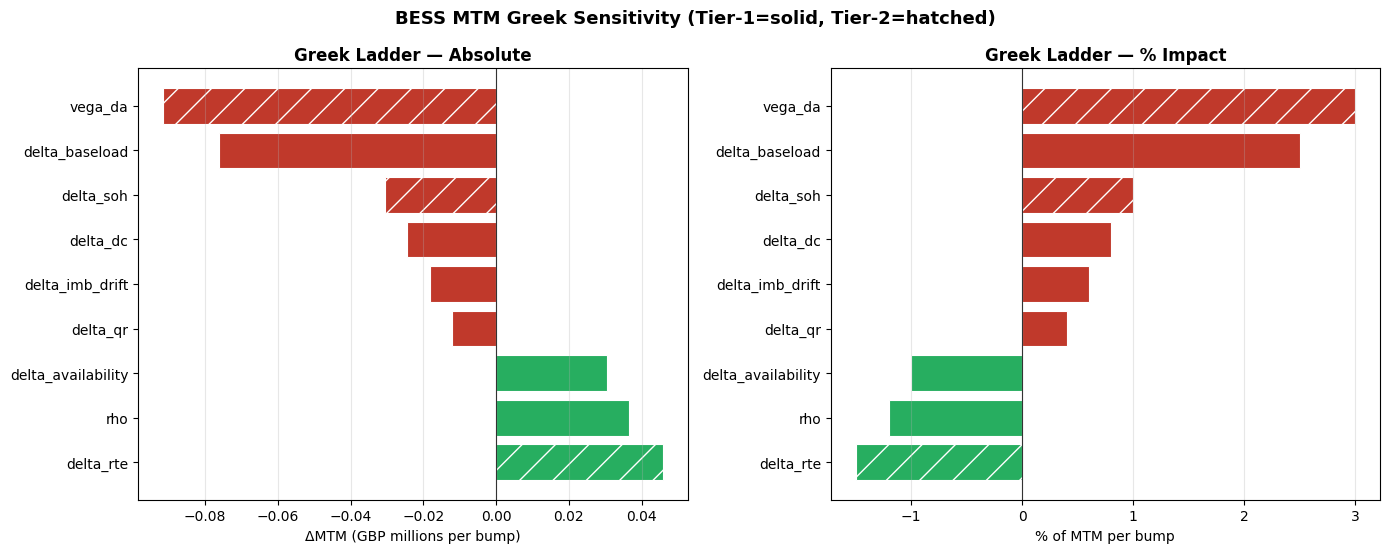

In [9]:
# Greek ladder waterfall chart
sorted_greeks = sorted(greek_results.items(), key=lambda x: x[1].greek_pct)

names  = [g.name for _, g in sorted_greeks]
deltas = [(g.bumped_mtm - g.base_mtm) / 1e6 for _, g in sorted_greeks]
pcts   = [g.greek_pct for _, g in sorted_greeks]
tiers  = [g.tier for _, g in sorted_greeks]

colors = ["#c0392b" if d < 0 else "#27ae60" for d in deltas]
hatches = ["/" if t == "re-solve" else "" for t in tiers]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, max(5, len(names)*0.4 + 2)))

# Left: ΔMTM in GBP millions
bars = ax1.barh(names, deltas, color=colors, edgecolor="white", linewidth=0.8)
for bar, h in zip(bars, hatches):
    if h:
        bar.set_hatch(h)
ax1.axvline(0, color="#333", lw=0.8)
ax1.set_xlabel("ΔMTM (GBP millions per bump)")
ax1.set_title("Greek Ladder — Absolute", fontweight="bold")
ax1.grid(axis="x", alpha=0.3)

# Right: % of MTM
bars2 = ax2.barh(names, pcts, color=colors, edgecolor="white", linewidth=0.8)
for bar, h in zip(bars2, hatches):
    if h:
        bar.set_hatch(h)
ax2.axvline(0, color="#333", lw=0.8)
ax2.set_xlabel("% of MTM per bump")
ax2.set_title("Greek Ladder — % Impact", fontweight="bold")
ax2.grid(axis="x", alpha=0.3)

plt.suptitle("BESS MTM Greek Sensitivity (Tier-1=solid, Tier-2=hatched)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PROCESSED / "greek_ladder.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. VaR / CVaR


In [10]:
# Risk metrics at multiple confidence levels
risk_multi = risk_metrics_multi_alpha(mtm, alphas=[0.90, 0.95, 0.99])

for alpha, rm in risk_multi.items():
    print_risk_summary(rm)


alpha=90%  VaR=GBP 3,508,313  CVaR=GBP 3,614,735  mean=GBP -3,051,461
alpha=95%  VaR=GBP 3,588,794  CVaR=GBP 3,680,877  mean=GBP -3,051,461
alpha=99%  VaR=GBP 3,784,654  CVaR=GBP 3,851,141  mean=GBP -3,051,461


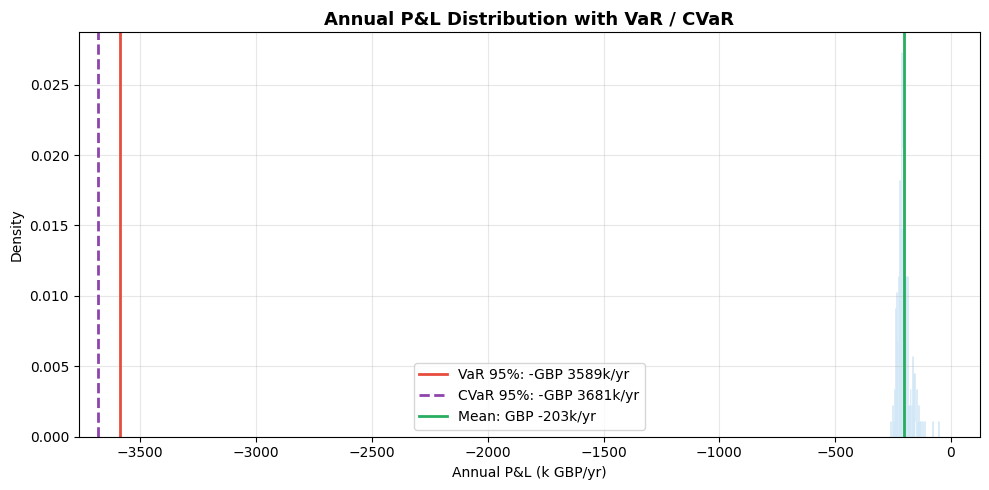

In [11]:
# VaR chart: annual PnL distribution with risk markers
rm = risk_multi[0.95]
annual_pnl = mtm.mtm_paths / mtm.life_years / 1e3   # k GBP/yr

fig, ax = plt.subplots(figsize=(10, 5))
n, bins, patches = ax.hist(annual_pnl, bins=60, density=True,
                            color="#3498db", edgecolor="white",
                            linewidth=0.5, alpha=0.85)

# Shade tail (VaR region)
var_cut_k = -rm.var_gbp / 1e3
for patch, left in zip(patches, bins[:-1]):
    if left < var_cut_k:
        patch.set_facecolor("#e74c3c")
        patch.set_alpha(0.9)

ax.axvline(var_cut_k, color="#e74c3c", lw=2,
           label=f"VaR 95%: -GBP {rm.var_gbp/1e3:.0f}k/yr")
ax.axvline(-rm.cvar_gbp/1e3, color="#8e44ad", lw=2, ls="--",
           label=f"CVaR 95%: -GBP {rm.cvar_gbp/1e3:.0f}k/yr")
ax.axvline(np.mean(annual_pnl), color="#27ae60", lw=2, ls="-",
           label=f"Mean: GBP {np.mean(annual_pnl):.0f}k/yr")

ax.set_xlabel("Annual P&L (k GBP/yr)")
ax.set_ylabel("Density")
ax.set_title("Annual P&L Distribution with VaR / CVaR",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PROCESSED / "var_cvar.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Scenario Stress Tests


In [12]:
scenarios = run_scenarios(mtm, alpha=0.95)
print_scenario_table(scenarios)


Scenario                      MTM GBP    Delta %
High price                 -3,509,180      15.0%
Low price                  -2,593,741     -15.0%
High volatility            -3,295,577       8.0%
Low ancillary              -2,837,858      -7.0%
High discount              -2,898,888      -5.0%


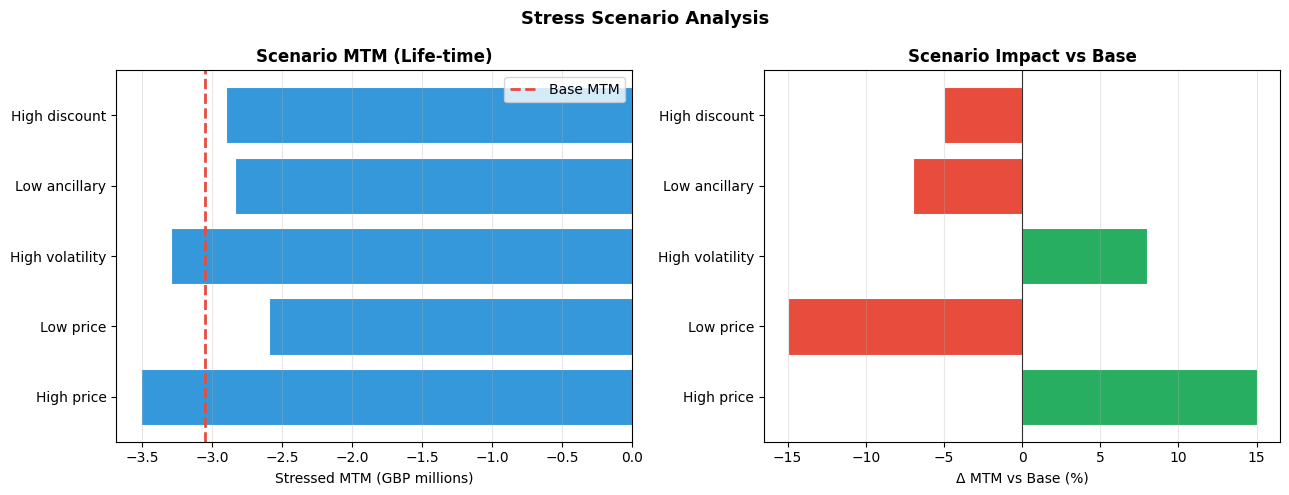

In [13]:
# Scenario comparison chart
sc_names  = list(scenarios.keys())
sc_means  = [s.stress_mtm_mean / 1e6 for s in scenarios.values()]
sc_deltas = [s.delta_pct for s in scenarios.values()]
sc_colors = ["#27ae60" if d >= 0 else "#e74c3c" for d in sc_deltas]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.barh(sc_names, sc_means, color="#3498db", edgecolor="white", linewidth=0.8)
ax1.axvline(mtm.mtm_mean/1e6, color="#e74c3c", lw=2, ls="--", label="Base MTM")
ax1.set_xlabel("Stressed MTM (GBP millions)")
ax1.set_title("Scenario MTM (Life-time)", fontweight="bold")
ax1.legend()
ax1.grid(axis="x", alpha=0.3)

ax2.barh(sc_names, sc_deltas, color=sc_colors, edgecolor="white", linewidth=0.8)
ax2.axvline(0, color="#333", lw=0.8)
ax2.set_xlabel("Δ MTM vs Base (%)")
ax2.set_title("Scenario Impact vs Base", fontweight="bold")
ax2.grid(axis="x", alpha=0.3)

plt.suptitle("Stress Scenario Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PROCESSED / "scenario_stress.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Save Summary


In [14]:
import os
PROCESSED.mkdir(parents=True, exist_ok=True)

summary = {
    "mtm": {
        **mtm.summary_gbp_mw_yr(),
        "annuity_factor":   mtm.annuity_factor,
        "alpha_merchant":   mtm.alpha_merchant,
        "life_years":       mtm.life_years,
    },
    "risk_95": risk_multi[0.95].to_dict(),
    "risk_99": risk_multi[0.99].to_dict(),
    "greeks": greeks_to_dict(greek_results),
    "scenarios": scenarios_to_dict(scenarios),
}

out = PROCESSED / "mtm_summary.json"
with open(out, "w") as f:
    json.dump(summary, f, indent=2)

print(f"Saved: {out}")
print(f"\nKey outputs:")
print(f"  MTM mean:     GBP {mtm.mtm_mean/1e6:.2f}M")
print(f"  MTM P5/P95:   GBP {mtm.mtm_p5/1e6:.2f}M / {mtm.mtm_p95/1e6:.2f}M")
print(f"  VaR 95%:      GBP {risk_multi[0.95].var_gbp/1e3:,.0f}k / yr")
print(f"  CVaR 95%:     GBP {risk_multi[0.95].cvar_gbp/1e3:,.0f}k / yr")


Saved: G:\My Drive\Research\bess_project\data\processed\mtm_summary.json

Key outputs:
  MTM mean:     GBP -3.05M
  MTM P5/P95:   GBP -3.59M / -2.28M
  VaR 95%:      GBP 3,589k / yr
  CVaR 95%:     GBP 3,681k / yr
